In [1]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt

%matplotlib inline

In [2]:
def drawBannerText(frame, text, banner_height_percent=0.08, font_scale=.8, text_color=(0, 255, 0), 
                   font_thickness=2):
    # Draw a black filled banner across the top of the image frame.
    # percent: set the banner height as a percentage of the frame height.
    banner_height = int(banner_height_percent * frame.shape[0])
    cv2.rectangle(frame, (0, 0), (frame.shape[1], banner_height), (0, 0, 0), thickness=-1)

    # Draw text on banner.
    left_offset = 20
    location = (left_offset, int(15 + (banner_height_percent * frame.shape[0]) / 2))
    cv2.putText(frame, text, location, cv2.FONT_HERSHEY_SIMPLEX, font_scale, text_color, 
                font_thickness, cv2.LINE_AA)

def drawRectangle(frame, bbox, color=(255,0,0)):
    p1 = (int(bbox[0]), int(bbox[1]))
    p2 = (int(bbox[0] + bbox[2]), int(bbox[1] + bbox[3]))
    cv2.rectangle(frame, p1, p2, color, 2, 1)

def displayRectangle(frame, bbox, color=(255,0,0)):
    plt.figure(figsize=(20,10))
    frameCopy = frame.copy()
    drawRectangle(frameCopy, bbox, color)
    frameCopy = cv2.cvtColor(frameCopy, cv2.COLOR_RGB2BGR)
    plt.imshow(frameCopy); plt.axis('off')    
     
def drawText(frame, text, location=(20,20), font_scale=1, color=(50,170,50), font_thickness=2):
    cv2.putText(frame, text, location, cv2.FONT_HERSHEY_SIMPLEX, font_scale, color, 
                font_thickness, cv2.LINE_AA)

In [3]:
# # Set up tracker.
# tracker_types = ['BOOSTING', 'CSRT', 'KCF', 'MEDIANFLOW', 'MIL', 'MOSSE', 'TLD']

# # Change the index to change the tracker type.
# tracker_type = tracker_types[0] 

# if tracker_type == 'BOOSTING':
#     tracker = cv2.legacy.TrackerBoosting_create()
# elif tracker_type == 'CSRT':
#     tracker = cv2.legacy.TrackerCSRT_create()
# elif tracker_type == 'KCF':
#     tracker = cv2.legacy.TrackerKCF_create()
# elif tracker_type == 'MEDIANFLOW':
#     tracker = cv2.legacy.TrackerMedianFlow_create()  
# elif tracker_type == 'MIL':
#     tracker = cv2.legacy.TrackerMIL_create()
# elif tracker_type == 'MOSSE':
#     tracker = cv2.legacy.TrackerMOSSE_create()
# elif tracker_type == 'TLD':
#     tracker = cv2.legacy.TrackerTLD_create()
# Change the index to change the tracker type.
tracker_type = 'MIL'
if tracker_type == 'MIL':
    tracker = cv2.TrackerMIL_create()

In [4]:
import sys

# Read video
video_input_file_name = "data/videos/race_car.mp4"

# Create output file name for annotated video.
video_output_file_name = os.path.splitext(os.path.basename(video_input_file_name))[0]  \
                       + "_"  + tracker_type + '.mp4'

# Create video capture object.
video_cap = cv2.VideoCapture(video_input_file_name)

# Read first frame from video.
ok, frame = video_cap.read()

# Confirm video file can be opened.
if video_cap.isOpened():
    width  = int(video_cap.get(cv2.CAP_PROP_FRAME_WIDTH))
    height = int(video_cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
    fps    = int(video_cap.get(cv2.CAP_PROP_FPS))
else: 
    print('Could not open video')
    sys.exit()
    
fps_write = 20    # slow down video for demonstration purposes.

# Set up video writer for mp4.
fourcc = cv2.VideoWriter_fourcc(*'mp4v')

# Create video writer object.
video_out = cv2.VideoWriter( video_output_file_name, fourcc, fps_write, (width, height) )

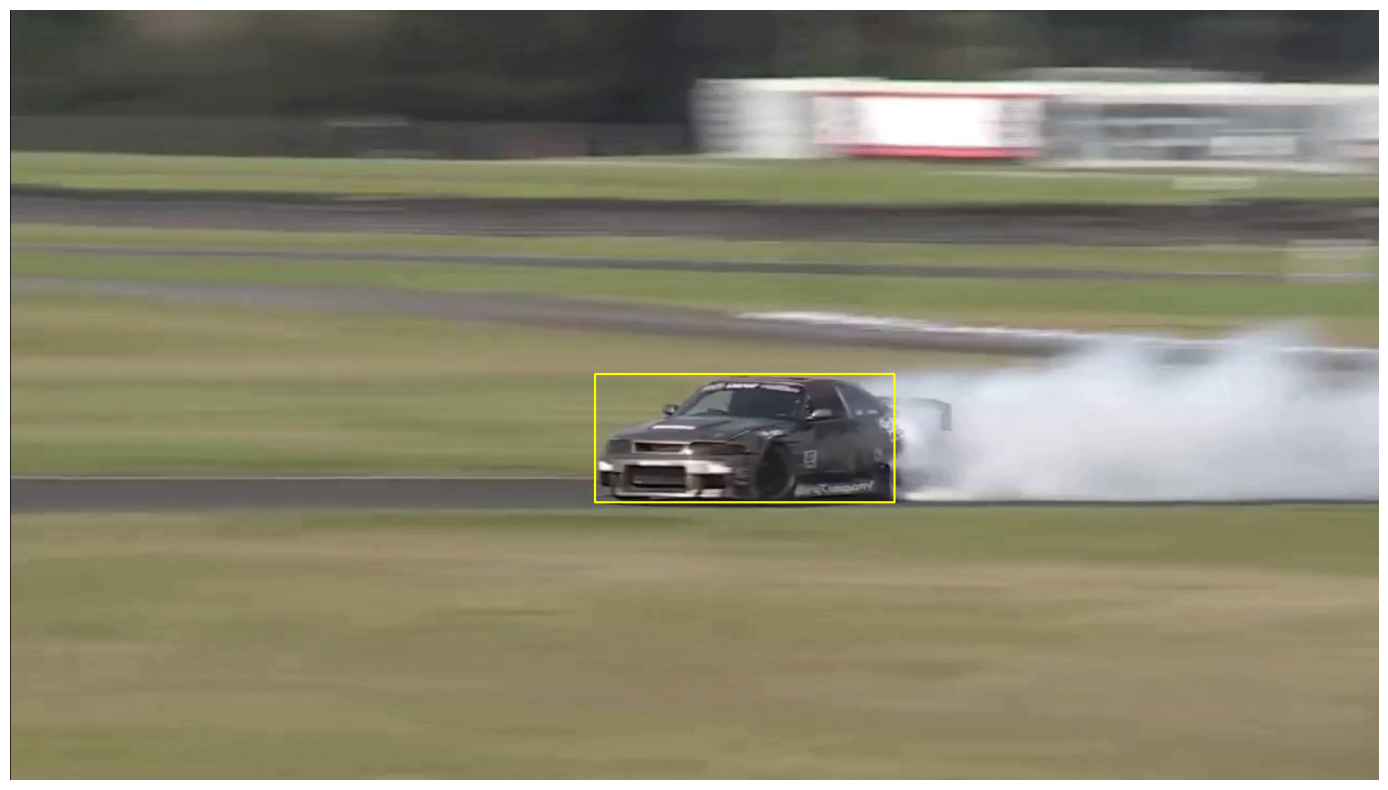

In [5]:
bbox = None
# Define a bounding box for the location of the object in the first video frame.
bbox = (820, 510, 420, 180) # race car

# Check if the a bounding box has been defined. If not, display the initial frame and alow the user to  
# manually select the bounding box with the mouse.
if bbox == None:
    # This will display the first frame of the video. Use the mouse to specify a bounding box
    # around the object to track. When done, hit the space bar or Enter key to complete the operation.
    bbox = cv2.selectROI(frame, False)  # Note: this may cause python to hang on Mac OS.
    print(bbox)
    
frame_copy = frame.copy() 
displayRectangle(frame_copy, bbox, color=(0, 255, 255))

In [6]:
tracker.init(frame, bbox);

In [7]:
while True:
    ok, frame = video_cap.read()
    if not ok:
        break 
    
    # Start timer
    timer = cv2.getTickCount()

    # Update tracker
    ok, bbox = tracker.update(frame)

    # Calculate Frames per second (FPS)
    fps = cv2.getTickFrequency() / (cv2.getTickCount() - timer);

    # Draw bounding box
    if ok:
        drawRectangle(frame, bbox, color=(0, 255, 255))
    else:
        drawText(frame, 'Tracking failure detected', location=(80,140), color=(0, 0, 255))

    # Display Info
    drawBannerText(frame, tracker_type + ' Tracker' + ', FPS : ' + str(int(fps)))
    
    # Write frame to video
    video_out.write(frame)
    
video_cap.release()
video_out.release()